In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from voltage_divider_data import load_all_data
from voltage_divider_plots import *

In [2]:
simulation = "data/simulation_v2.csv"
data = "data/VoltageDivider_v2.xlsx"

In [3]:
data = load_all_data(excel_path=data, simulation_path=simulation)
list(vars(data))
## data = load_all_data(include_intermediate=True) include "raw" pandas dataframes - for debugging purposes only

# data.sim_df
# data.measurement_df
# data.comparison_df

['measurement_df', 'sim_df', 'comparison_df']

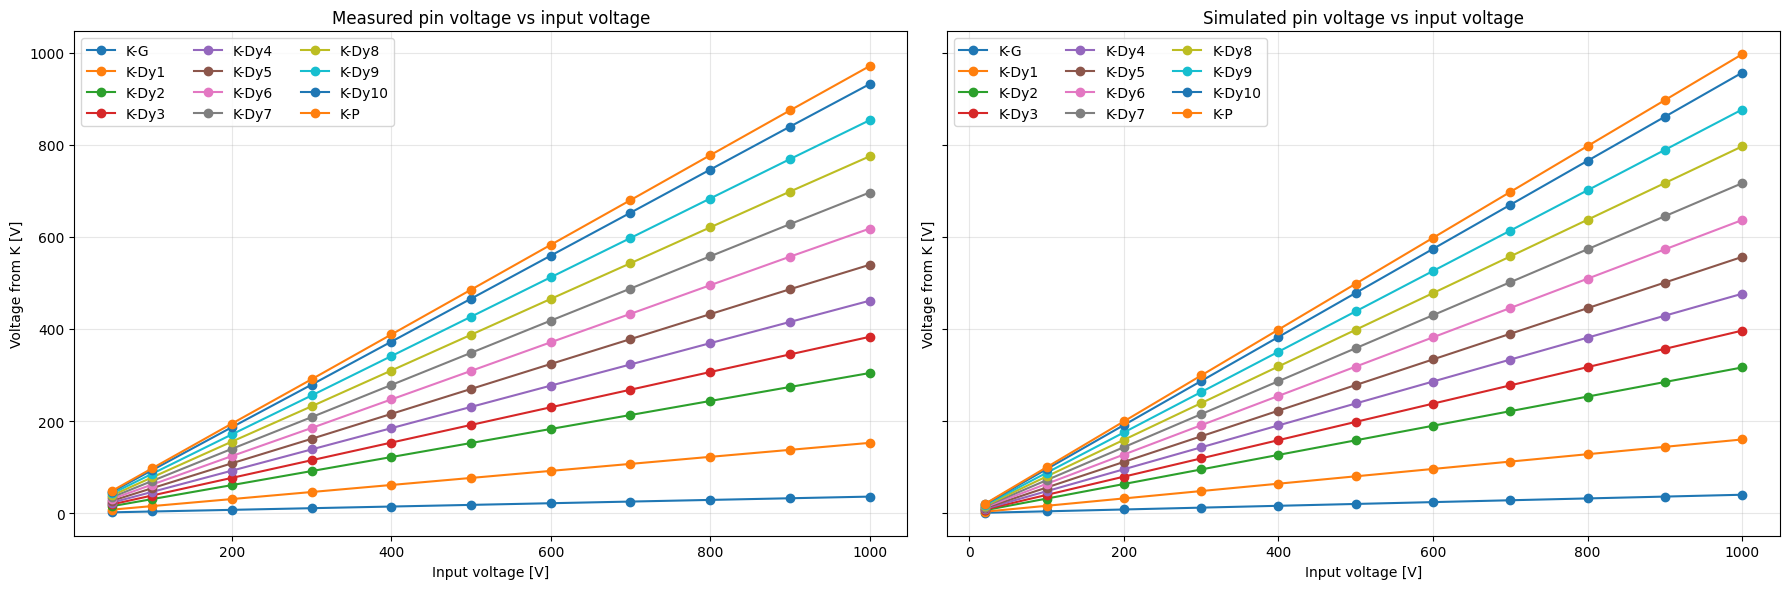

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

plot_pin_voltage_vs_input_voltage(
    data,
    source="measured",
    ax=axes[0],
    title=None,
    show=False,
)

plot_pin_voltage_vs_input_voltage(
    data,
    source="simulated",
    ax=axes[1],
    title=None,
    show=False,
)

fig.tight_layout()
plt.show()


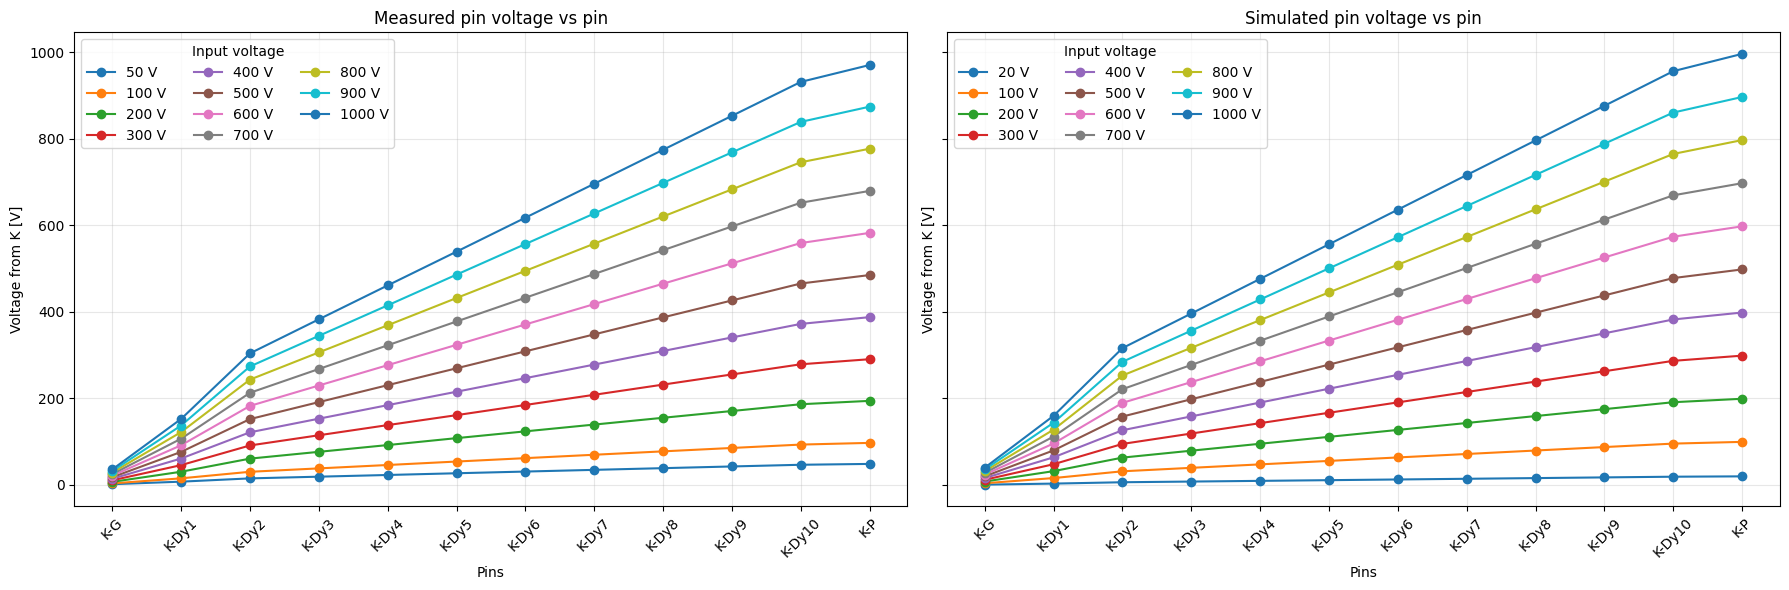

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

plot_pin_voltage_vs_pin(
    data,
    source="measured",
    ax=axes[0],
    title=None,
    show=False,
)

plot_pin_voltage_vs_pin(
    data,
    source="simulated",
    ax=axes[1],
    title=None,
    show=False,
)

fig.tight_layout()
plt.show()


# Data vs. Simulation

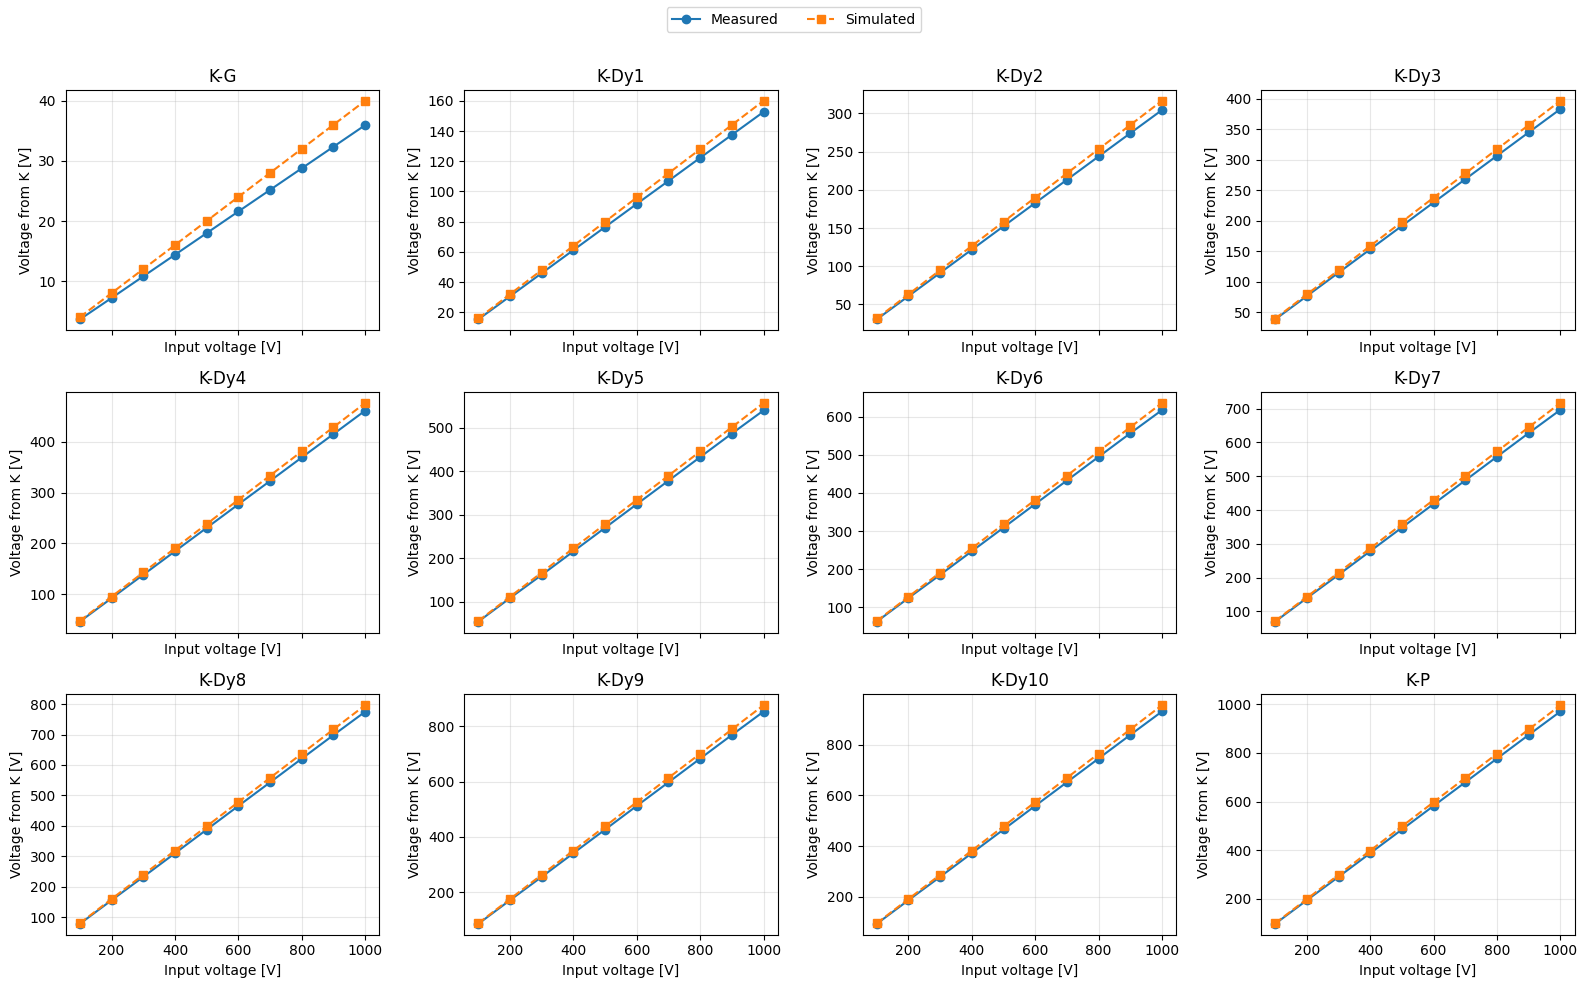

In [6]:
plot_by_pin(data.comparison_df);

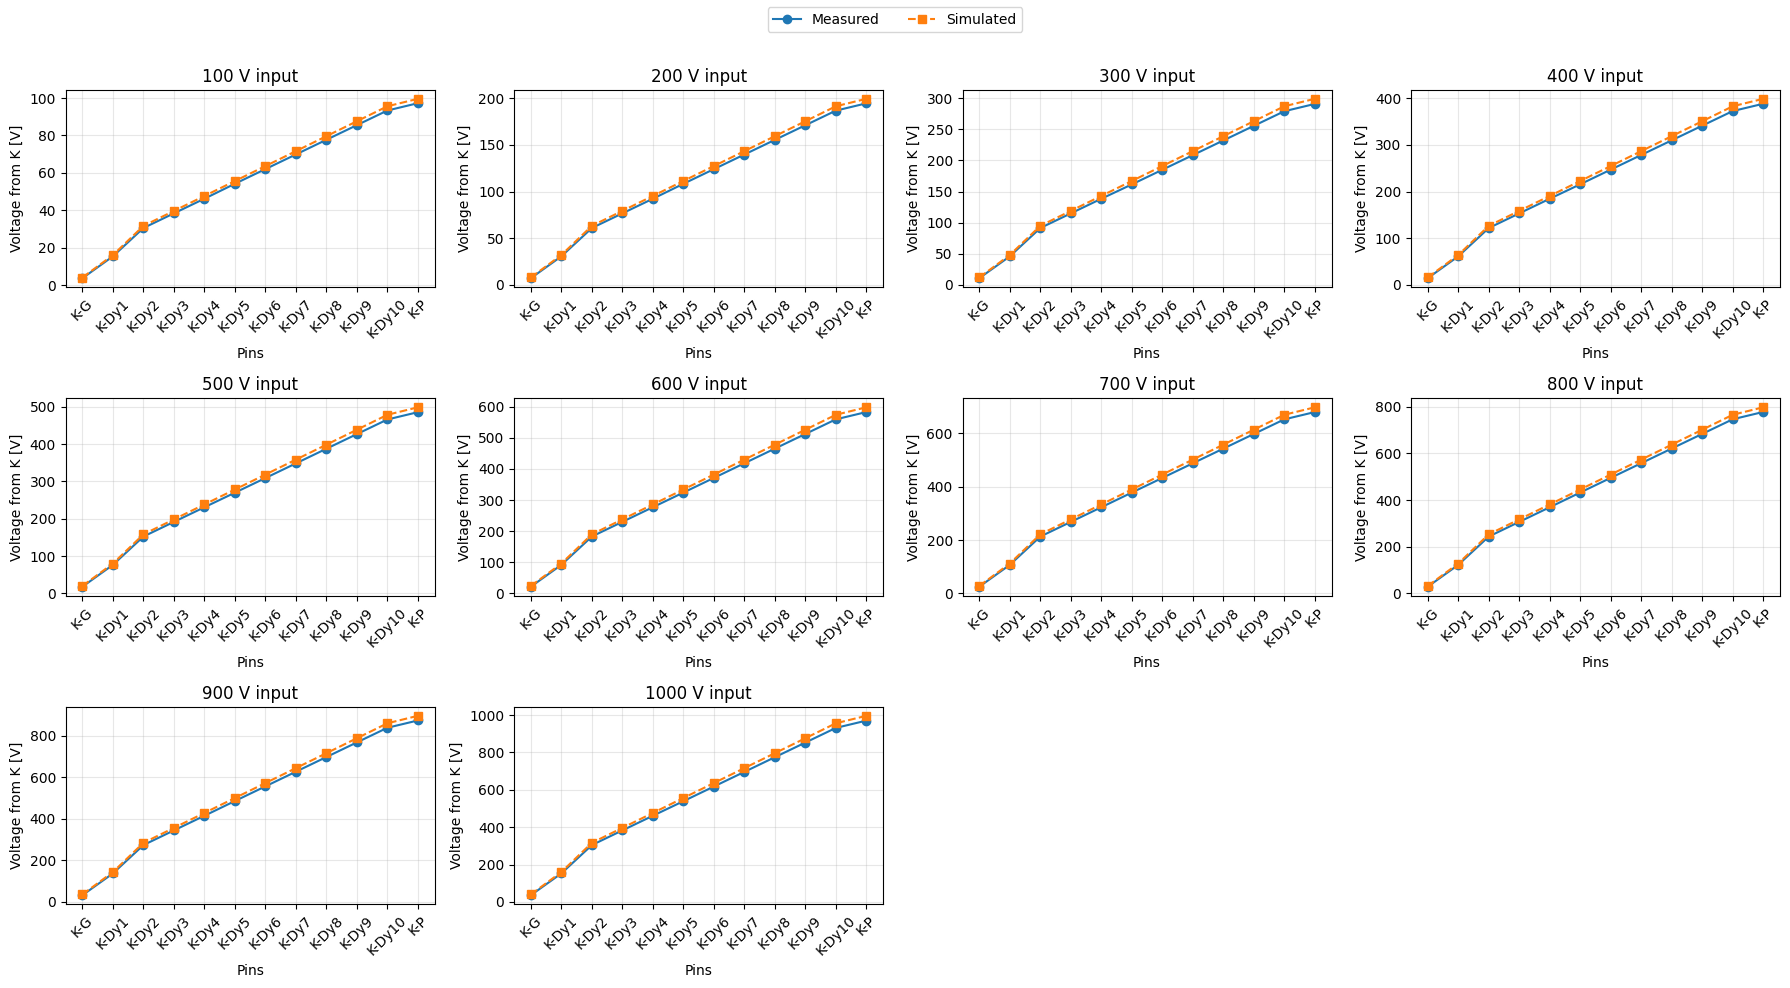

In [7]:
plot_by_input_voltage(data.comparison_df);

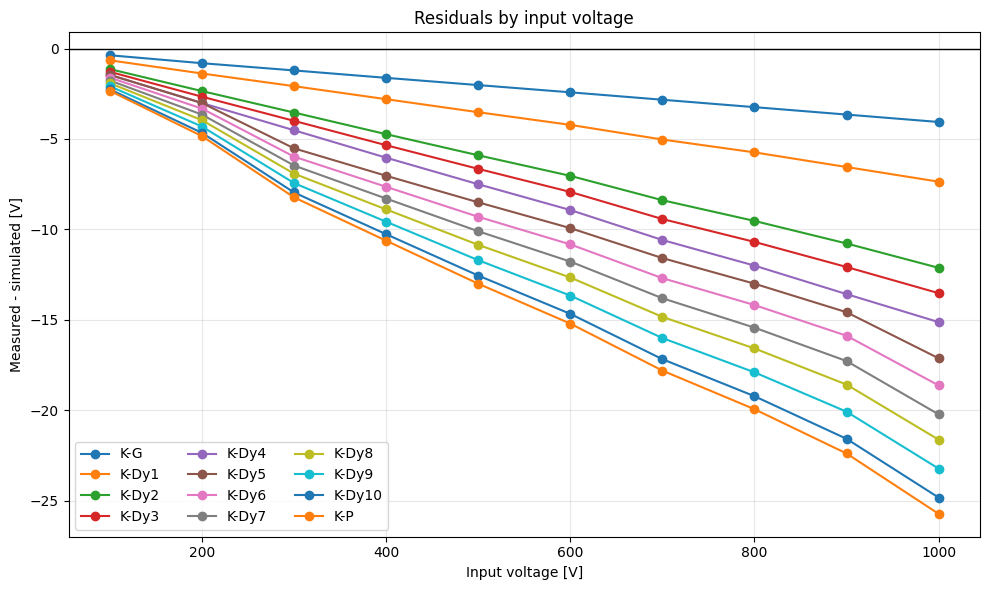

In [8]:
plot_residuals_by_voltage(data.comparison_df);


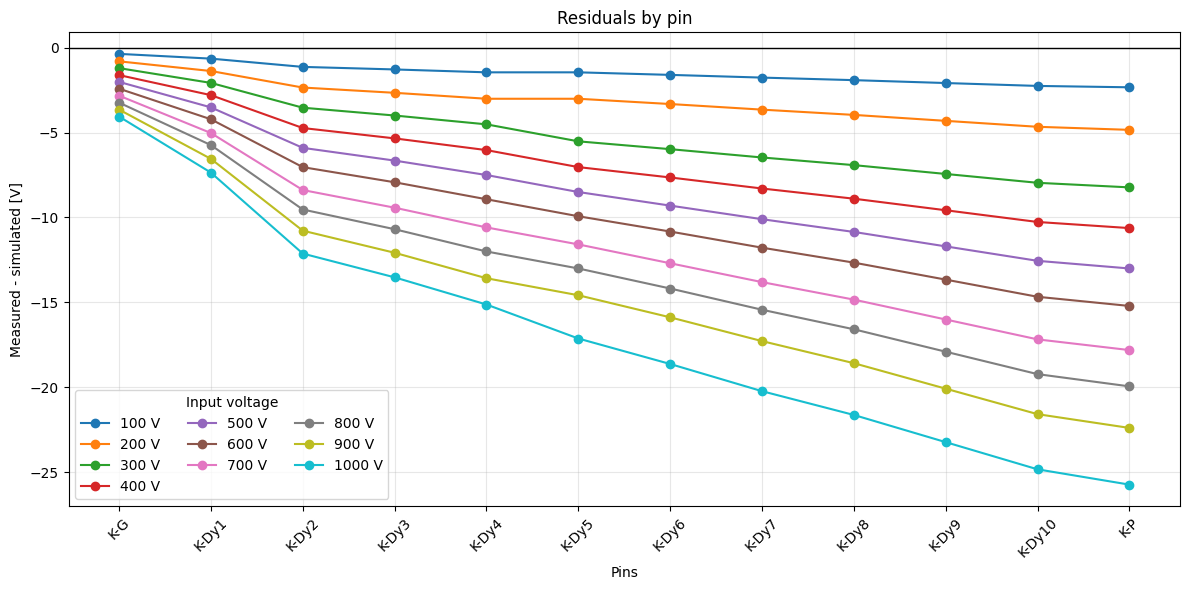

In [9]:
plot_residuals_by_pin(data.comparison_df);

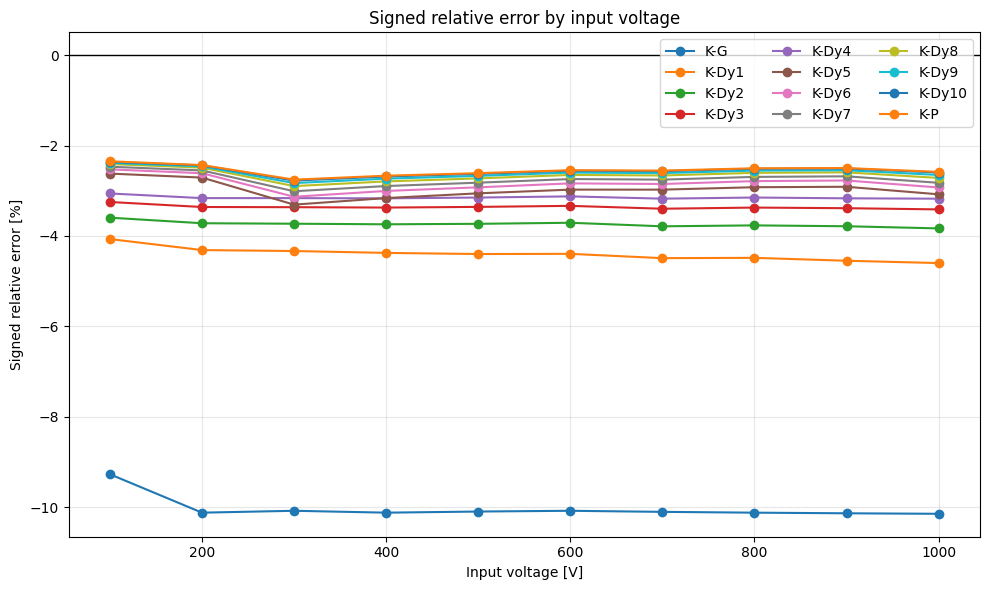

In [10]:
plot_relative_error_by_voltage(data.comparison_df);


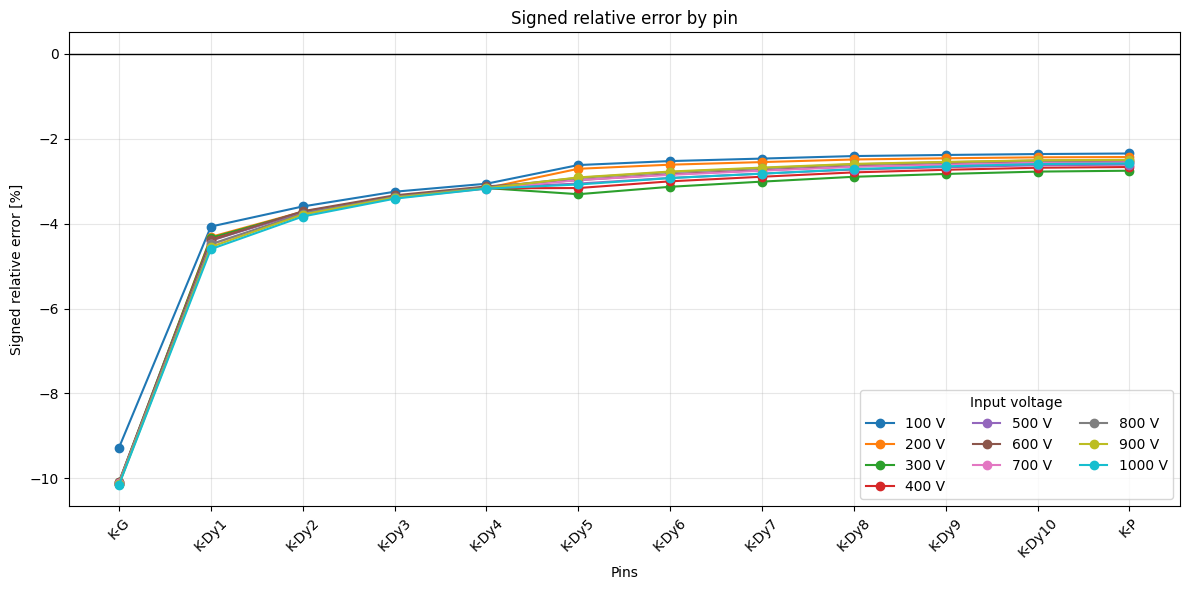

In [11]:
plot_relative_error_by_pin(data.comparison_df);

In [ ]:
MEASURED_PIN_ORDER = [
    "K-G",
    "G-Dy1",
    "Dy1-Dy2",
    "Dy2-Dy3",
    "Dy3-Dy4",
    "Dy4-Dy5",
    "Dy5-Dy6",
    "Dy6-Dy7",
    "Dy7-Dy8",
    "Dy8-Dy9",
    "Dy9-Dy10",
    "Dy10-P",
]

CUMULATIVE_PIN_ORDER = ["K-G"] + [f"K-Dy{i}" for i in range(1, 11)] + ["K-P"]



In [18]:
data.comparison_df

,input_voltage_V,pins,measured_voltage_V,simulated_voltage_V,delta_V,signed_relative_error_percent
0,100.0,K-G,3.629,4.000,-0.371,-9.275000
1,200.0,K-G,7.190,8.000,-0.810,-10.125000
2,300.0,K-G,10.790,12.000,-1.210,-10.083333
3,400.0,K-G,14.380,16.000,-1.620,-10.125000
4,500.0,K-G,17.980,20.000,-2.020,-10.100000
...,...,...,...,...,...,...
115,600.0,K-P,582.610,597.818,-15.208,-2.543918
116,700.0,K-P,679.650,697.455,-17.805,-2.552853
117,800.0,K-P,777.150,797.091,-19.941,-2.501722
118,900.0,K-P,874.340,896.727,-22.387,-2.496523


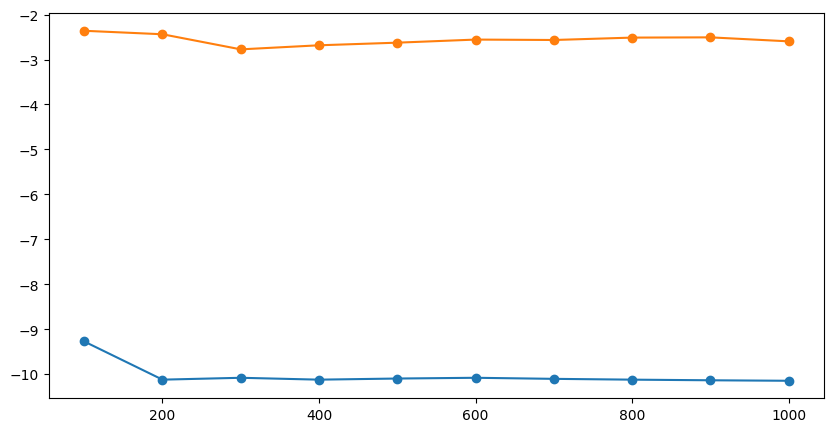

In [21]:
error_column = "signed_relative_error_percent"

fig, ax = plt.subplots(figsize=(10, 5))

for pin in ["K-G", "K-Dy10"]:
    pin_df = data.comparison_df[data.comparison_df["pins"] == pin]
    ax.plot(
        pin_df["input_voltage_V"],
        pin_df[error_column],
        "o-",
        label=pin,
        )

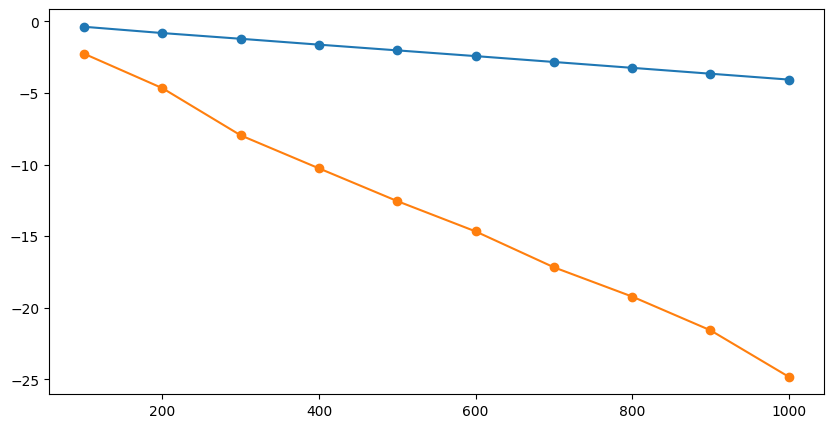

In [22]:
error_column = "delta_V"

fig, ax = plt.subplots(figsize=(10, 5))

for pin in ["K-G", "K-Dy10"]:
    pin_df = data.comparison_df[data.comparison_df["pins"] == pin]
    ax.plot(
        pin_df["input_voltage_V"],
        pin_df[error_column],
        "o-",
        label=pin,
        )